In [1]:
from __future__ import print_function
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
from sklearn import preprocessing
import pydot

from graphviz import Source


%matplotlib inline
plt.rcParams["figure.figsize"] = (15, 8)
pd.options.display.float_format = '{:.2f}'.format

# Деревья решений

| Outlook | Temperature | Humidity | Wind | Play |
| --- | --- | --- | --- | --- |
|Sunny | 85 | 85 | false | no |
|Sunny | 80 | 90 | true | no |
|Overcast | 83 | 86 | false | yes |
|Rainy | 70 | 96 | false | yes |
|Rainy | 68 | 80 | false | yes |
|Rainy | 65 | 70 | true | no |
|Overcast | 64 | 65 | true | yes |
|Sunny | 72 | 95 | false | no |
|Sunny | 69 | 70 | false | yes |
|Rainy | 75 | 80 | false | yes |
|Sunny | 75 | 70 | true | yes |
|Overcast | 72 | 90 | true | yes |
|Overcast | 81 | 75 | false | yes |
|Rainy | 71 | 91 | true | no |

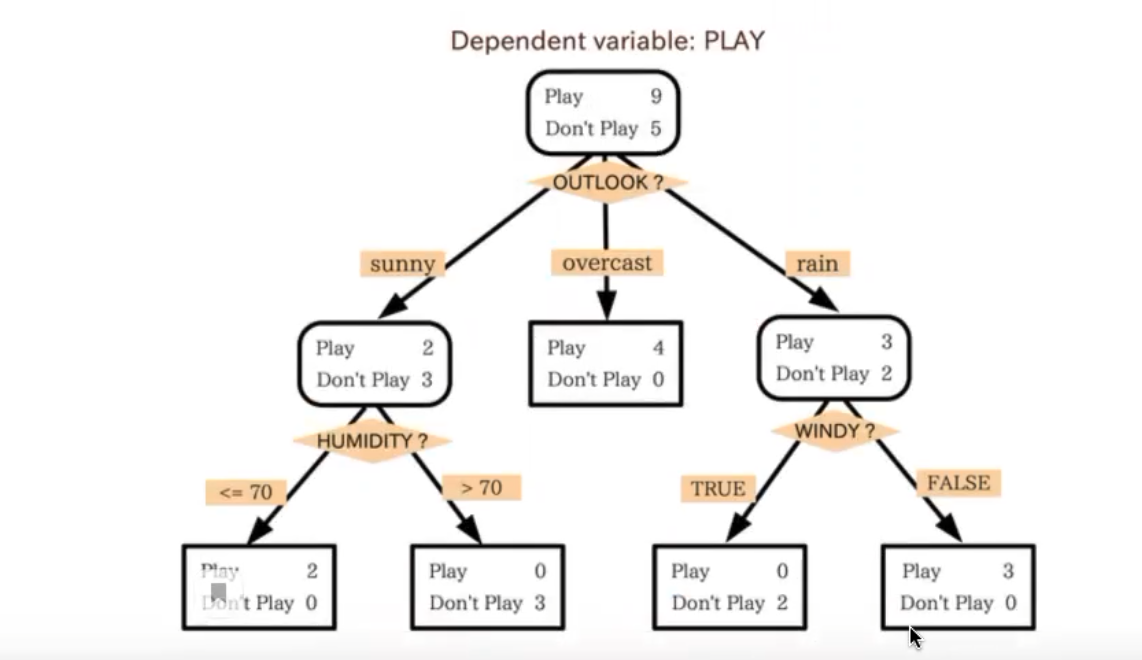

Формально, дерево решений - это связный ациклический граф. В нем можно выделить 3 типа вершин:
1. Корневая вершина (root node) -  откуда все начинается
2. Внутренние вершины (intermediate nodes)
3. Листья (leafs) - самые глубокие вершины дерева, в которых содержится "ответ"

Во внутренней или коневой вершине признак проверяется на некий логический критерий, по результатам которого мы движемся все глубже

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target
tree_clf = DecisionTreeClassifier(max_depth=2) # max_depth - максимальная глубина
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


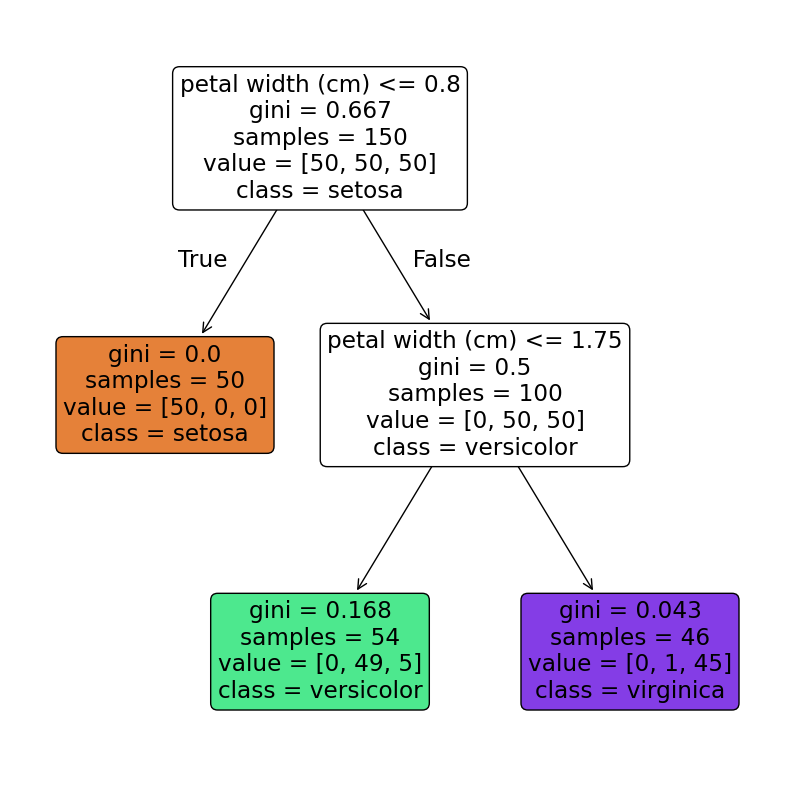

In [3]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 10))

# 2. Построение дерева решений
plot_tree(
    tree_clf,
    feature_names=iris.feature_names[2:],  # Используем только последние два признака
    class_names=iris.target_names,
    filled=True,  # Окрашивает узлы в зависимости от преобладающего класса
    rounded=True,  # Скругляет углы у блоков
)

# 3. Отображение или сохранение
plt.show()

In [4]:
import sys
if sys.version_info[0] < 3: 
    from StringIO import StringIO
else:
    from io import StringIO


golf = StringIO("""Outlook,Temperature,Humidity,Wind,Play
Sunny,85,85,false,no
Sunny,80,90,true,no
Overcast,83,86,false,yes
Rainy,70,96,false,yes
Rainy,68,80,false,yes
Rainy,65,70,true,no
Overcast,64,65,true,yes
Sunny,72,95,false,no
Sunny,69,70,false,yes
Rainy,75,80,false,yes
Sunny,75,70,true,yes
Overcast,72,90,true,yes
Overcast,81,75,false,yes
Rainy,71,91,true,no
""")

df = pd.read_csv(golf, sep=',')

In [5]:
df

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,85,85,False,no
1,Sunny,80,90,True,no
2,Overcast,83,86,False,yes
3,Rainy,70,96,False,yes
4,Rainy,68,80,False,yes
5,Rainy,65,70,True,no
6,Overcast,64,65,True,yes
7,Sunny,72,95,False,no
8,Sunny,69,70,False,yes
9,Rainy,75,80,False,yes


In [6]:
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']] 
y = df[['Play']]
tree_clf = DecisionTreeClassifier(max_depth=2)

In [7]:
X

,Outlook,Temperature,Humidity,Wind
0,Sunny,85,85,False
1,Sunny,80,90,True
2,Overcast,83,86,False
3,Rainy,70,96,False
4,Rainy,68,80,False
5,Rainy,65,70,True
6,Overcast,64,65,True
7,Sunny,72,95,False
8,Sunny,69,70,False
9,Rainy,75,80,False


In [8]:
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

d = defaultdict(LabelEncoder)
X = np.c_[
    df[['Outlook', 'Wind']].apply(lambda x: d[x.name].fit_transform(x)).values,
    df[['Temperature', 'Humidity']].values
]
y = df[['Play']].values
print(X)
print(y)

[[ 2  0 85 85]
 [ 2  1 80 90]
 [ 0  0 83 86]
 [ 1  0 70 96]
 [ 1  0 68 80]
 [ 1  1 65 70]
 [ 0  1 64 65]
 [ 2  0 72 95]
 [ 2  0 69 70]
 [ 1  0 75 80]
 [ 2  1 75 70]
 [ 0  1 72 90]
 [ 0  0 81 75]
 [ 1  1 71 91]]
[['no']
 ['no']
 ['yes']
 ['yes']
 ['yes']
 ['no']
 ['yes']
 ['no']
 ['yes']
 ['yes']
 ['yes']
 ['yes']
 ['yes']
 ['no']]


In [9]:
o = d['Outlook']

In [10]:
o.classes_

array(['Overcast', 'Rainy', 'Sunny'], dtype=object)

In [11]:
tree_clf = DecisionTreeClassifier(max_depth=3)
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


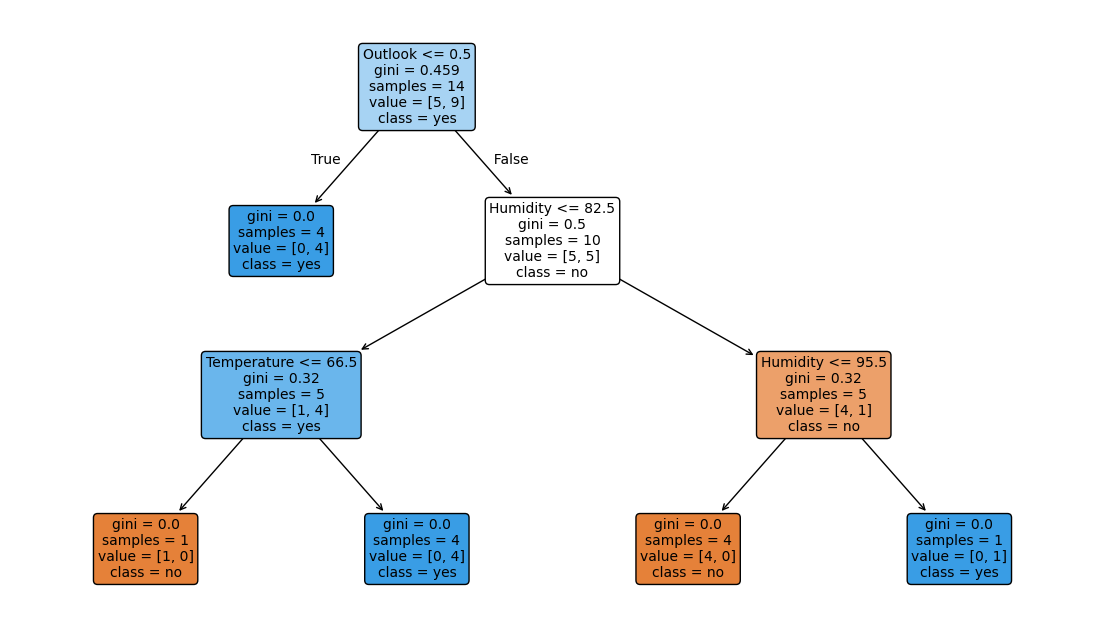

In [12]:
plt.figure(figsize=(14, 8), dpi=100)

feature_names = ["Outlook", "Wind", "Temperature", "Humidity"]
class_names = ["no", "yes"]

plot_tree(
    tree_clf,
    feature_names=feature_names, 
    class_names=class_names, 
    filled=True,  
    rounded=True,  
    fontsize=10,  
)

plt.show()

# Псевдокод алгоритма

```{python}
function decision_tree(X_N):
	if X_N satisfies leaf criterion:
		L = create_leaf(X_N)
		assign_class(L)
	else:
		L = create_node(X_N)
		X_1,..,X_S = split(L)
		for i in 1..S:
			C = decision_tree(X_i)
			add_child(L, C)
	return L  
```

# CART - Classification And Regression Trees
1. Как происходит разделение?
2. На сколько детей разделять каждый узел?
3. Какой критерий листа выбрать?
4. Как выбрать класс каждого листа?
5. Что делать, если часть значений отсутствует?

# Как делать разбиение?

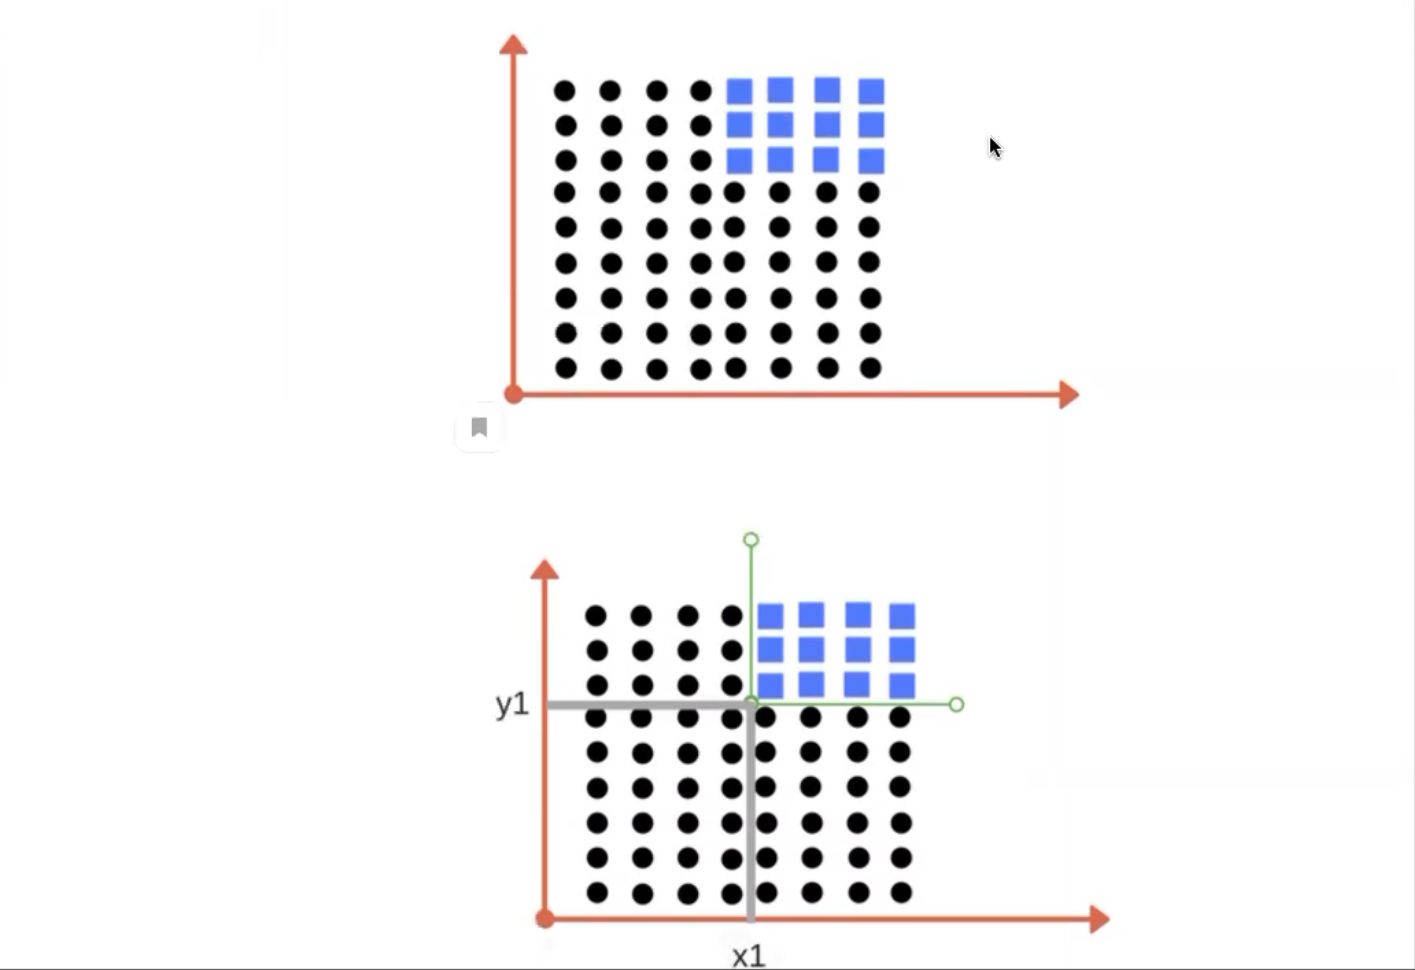

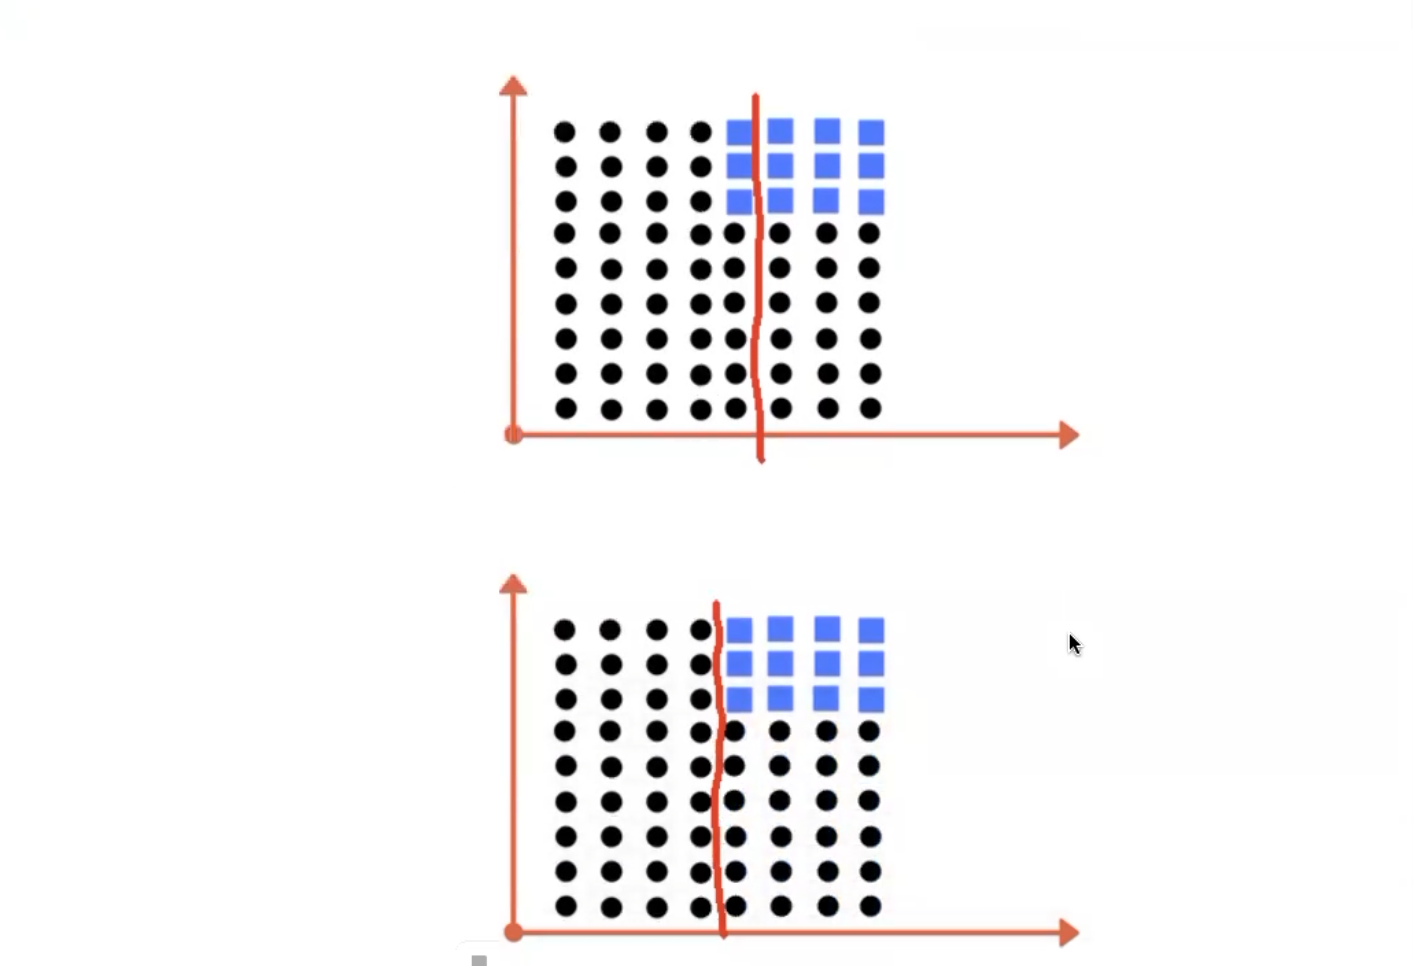

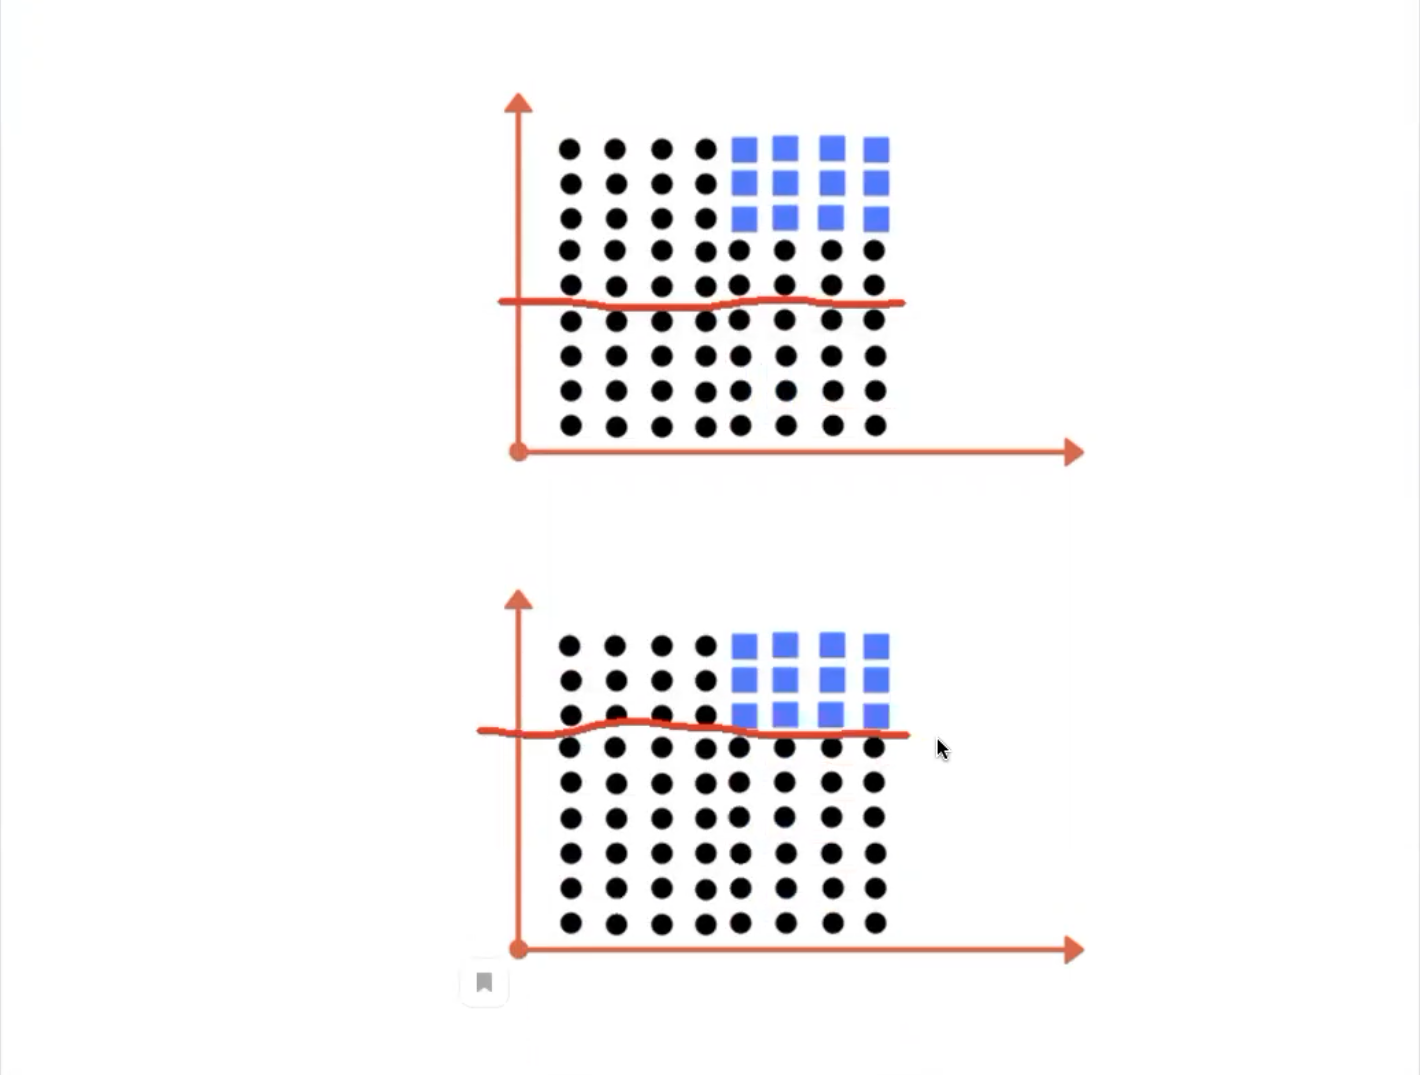

### Меры неопределенности (impurity measures)

Пусть $p_k$ - это доля класса $C_k$ в узле дерева $S$.

1. Missclassification error  
$$i(N) = 1 - \max_k p(x \in C_k)$$
2. Gini impurity
$$i(N) = 1 - \sum_k p^2(x \in C_k) = \sum_{i \neq j} p(x \in C_i) p(x \in C_j)$$
https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity 

3. Информационная энтропия
$$i(N) =  -\sum_k p(x \in C_k) \log_2 p(x \in C_k)$$


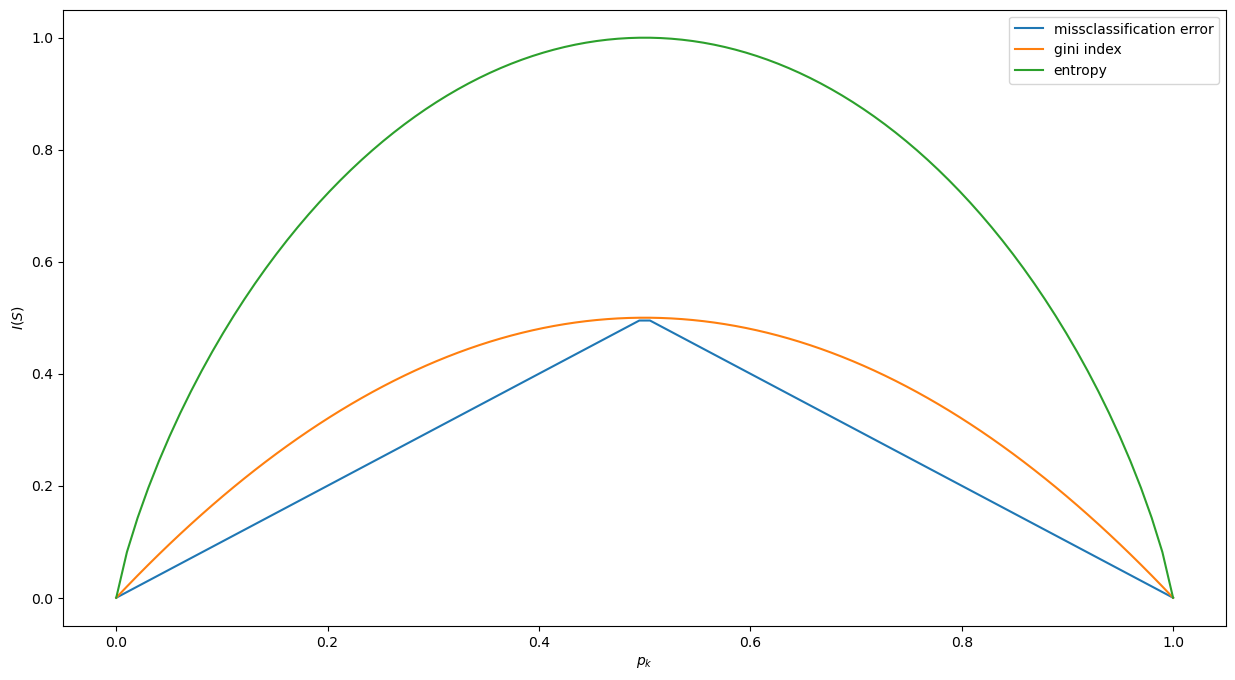

In [13]:
def plot_impurities():
    threshold = 0.000001
    p = np.linspace(0, 1, 100)
    p = np.c_[p, 1-p]

    missclass = 1 - p.max(axis=1)
    plt.plot(p[:,0], missclass, label = 'missclassification error')

    gini = 1 - (p ** 2).sum(axis=1)
    plt.plot(p[:,0], gini, label = 'gini index')

    entropy = - np.nansum((p * np.log2(np.clip(p, threshold, 1 - threshold))), axis=1)
    plt.plot(p[:,0], entropy, label = 'entropy')

    plt.xlabel('$p_k$')
    plt.ylabel('$I(S)$')
    plt.legend()
    
plot_impurities()

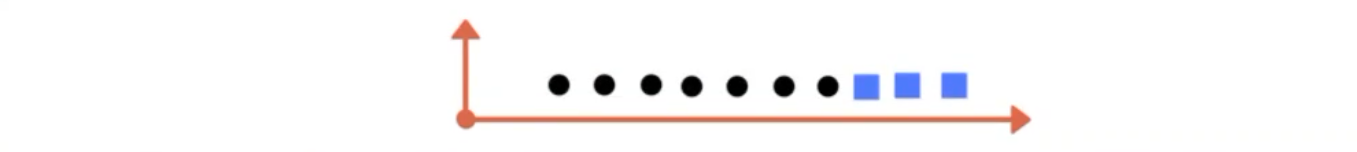

In [15]:
n = 10.

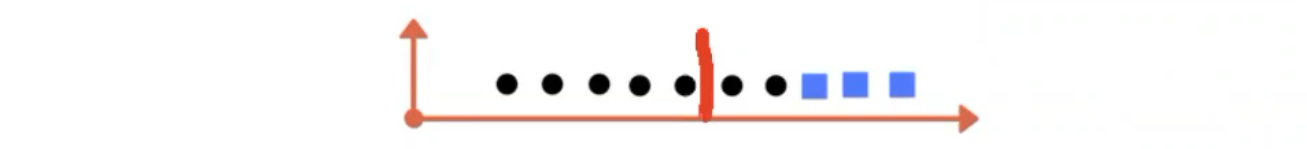

In [16]:
ME_1_left = 1 - 5./5
ME_1_left # 0

0.0

In [17]:
ME_1_right = 1 - 3 / 5.
ME_1_right # 4/10

0.4

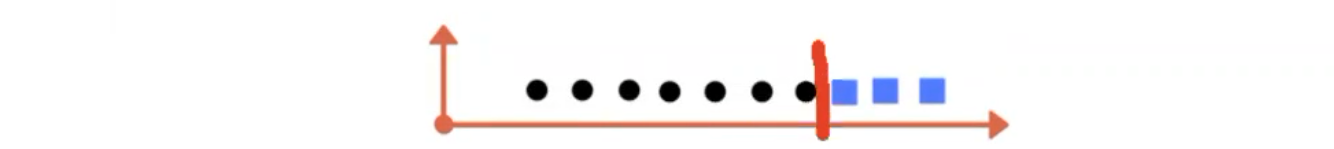

In [18]:
ME_2_left = 1 - 7./7
ME_2_left

0.0

In [19]:
ME_2_right = 1 - 3./3
ME_2_right

0.0

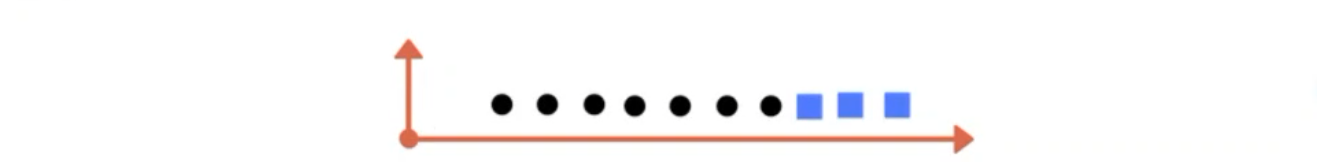

In [20]:
ME_all = 1 - 7. / 10
ME_all

0.30000000000000004

### Прирост информации

Выбрать признак и точку отсечения такими, чтобы было максимально уменьшение $impurity$
$$Information Gain = \Delta i(N, N_L, N_R) = i(N) - \frac {N_L}{N} i(N_L) - \frac {N_R}{N} i(N_R)$$

* Стратегия выбора - жадная
* Как определяется порог при вещественных признаках?
* Локальная оптимизация - уменьшение Impurity внутри узла
* Результаты не сильно зависят от выбора самой меры неопределенности


In [21]:
# 1
ME_all - ((5 / n) * ME_1_left + (5 / n) * ME_1_right)

0.10000000000000003

In [22]:
(5 / n) * ME_1_left, (5 / n) * ME_1_right

(0.0, 0.2)

In [23]:
# 2
ME_all - ((7 / n) * ME_2_left + (3 / n) * ME_2_right)

0.30000000000000004

In [24]:
(7 / n) * ME_2_left, (3 / n) * ME_2_right

(0.0, 0.0)

## Рассчет разбиения в выборке

In [25]:
df[['Temperature', 'Play']]

,Temperature,Play
0,85,no
1,80,no
2,83,yes
3,70,yes
4,68,yes
5,65,no
6,64,yes
7,72,no
8,69,yes
9,75,yes


In [26]:
df[['Temperature', 'Play']].sort_values('Temperature')

,Temperature,Play
6,64,yes
5,65,no
4,68,yes
8,69,yes
3,70,yes
13,71,no
7,72,no
11,72,yes
10,75,yes
9,75,yes


### Если разделение не бинарное

Естественный выбор при разделении на $B$ детей
$$\Delta i(N, N_1, \ldots, N_B) = i(N) - \sum_{k=1}^B \frac{N_k}{N} i(N_k) \rightarrow \max$$

Предпочтение отдается большим $B$. Модификация:
$$\Delta i_B(N, N_1, \ldots, N_B) = \frac{\Delta i(N, N_1, \ldots, N_B)}{-\sum_{k=1}^B \frac{N_k}{N} \log_2 \frac{N_k}{N}} \rightarrow \max$$


## Задание.

Проблемой данного алгоритма является переобучение. Каким образом можно избежать переобучения?

## Критерии останова (регуляризация)

* Никогда
* Задать порог по мере неопределенности: $I(S) \leq \theta$
* Задать порог по размеру узла: $|S| \leq n$
* Задать порог на глубину: $Depth(S) = d$
* Задать порог на размер потомков: $|S_L| \leq n_1 \& |S_R| \leq n_2$
* Использовать валидационную выборку
* ...

In [31]:
model = DecisionTreeClassifier(
    class_weight=None, 
    criterion='gini', 
    max_depth=3,
    max_features=None, 
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=1, 
    min_samples_split=2,
    min_weight_fraction_leaf=0.0, 
    random_state=None,
    splitter='best'
)